# Road Traffic Accidents in Great Britain, 2019: Analysis and Recommendations

An end-to-end analysis of the UK Department for Transport's **STATS19** road safety data for 2019: when accidents happen, which conditions are linked to serious and fatal outcomes (association-rule mining), where accidents cluster in Kingston upon Hull and East Riding of Yorkshire (k-means), and how well accident volumes can be forecast (XGBoost vs a naive baseline), finishing with evidence-based policy recommendations.

**Data:** DfT STATS19 road safety data (Open Government Licence v3.0), queried from a local SQLite database. See the README.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.cluster import KMeans
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error

In [2]:
#connect to the database 
DB_PATH = "accident_data_v1.0.0_2023.db"
try:
    con = sqlite3.connect(DB_PATH)
except sqlite3.Error as exc:
    raise RuntimeError(f"Could not open the accident database at '{DB_PATH}': {exc}") from exc

#execute SQL statements and fetch results from SQL queries
cur = con.cursor()

#### Data processing 

In [3]:
def get_columns(table_name):
    """Column names for a table, via PRAGMA table_info."""
    return [col[1] for col in cur.execute(f"PRAGMA table_info({table_name})").fetchall()]

def load_table(table_name, columns, year=None):
    """Fetch rows from `table_name` (optionally filtered to one accident_year)
    into a DataFrame. Raises a clear RuntimeError instead of a raw sqlite3
    traceback if the query fails."""
    query = f"SELECT * FROM {table_name}"
    if year is not None:
        query += f" WHERE accident_year = {year}"
    try:
        rows = cur.execute(query).fetchall()
    except sqlite3.Error as exc:
        raise RuntimeError(f"Failed to load '{table_name}' from the database: {exc}") from exc
    return pd.DataFrame(rows, columns=columns)

#column names for every table
accident_cols = get_columns('accident')
vehicle_cols = get_columns('vehicle')
casualty_cols = get_columns('casualty')
lsoa_cols = get_columns('lsoa')


accident_df = load_table('accident', accident_cols, year=2019)
display(accident_df.head(2))

vehicle_df = load_table('vehicle', vehicle_cols, year=2019)
display(vehicle_df.head(2))

casualty_df = load_table('casualty', casualty_cols, year=2019)
display(casualty_df.head(2))

lsoa_df = load_table('lsoa', lsoa_cols)
display(lsoa_df.head(2))

,accident_index,accident_year,accident_reference,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,accident_severity,number_of_vehicles,...,pedestrian_crossing_physical_facilities,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location
0,2019010128300,2019,010128300,528218.0,180407.0,-0.153842,51.508057,1,3,2,...,5,1,1,1,0,0,1,3,2,E01004762
1,2019010152270,2019,010152270,530219.0,172463.0,-0.127949,51.436208,1,3,2,...,9,4,1,1,0,0,1,3,2,E01003117


,vehicle_index,accident_index,accident_year,accident_reference,vehicle_reference,vehicle_type,towing_and_articulation,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,...,journey_purpose_of_driver,sex_of_driver,age_of_driver,age_band_of_driver,engine_capacity_cc,propulsion_code,age_of_vehicle,generic_make_model,driver_imd_decile,driver_home_area_type
0,465335,2019010128300,2019,010128300,1,9,0,99,9,9,...,6,1,58,9,-1,-1,-1,-1,2,1
1,465336,2019010128300,2019,010128300,2,9,0,99,9,9,...,6,3,-1,-1,-1,-1,-1,-1,2,1


,casualty_index,accident_index,accident_year,accident_reference,vehicle_reference,casualty_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,casualty_severity,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_home_area_type,casualty_imd_decile
0,331590,2019010128300,2019,010128300,1,1,1,1,58,9,3,0,0,0,0,0,9,1,2
1,331591,2019010128300,2019,010128300,1,2,2,2,-1,-1,3,0,0,1,0,0,9,1,5


,objectid,lsoa01cd,lsoa01nm,lsoa01nmw,shape__area,shape__length,globalid
0,1,E01000001,City of London 001A,City of London 001A,129865.232552,2635.772001,68cc6127-1008-4fbe-a16c-78fb089a7c43
1,2,E01000002,City of London 001B,City of London 001B,228418.896622,2707.986202,937edbc3-c1bf-4d35-b274-b0a1480a7c09


In [4]:
#load historical accidents data (2017-2020) 
accident_all_df = load_table('accident', accident_cols)

print(accident_all_df['accident_year'].value_counts().sort_index())

accident_year
2017    129982
2018    122635
2019    117536
2020     91199
Name: count, dtype: int64


### Data Cleaning and EDA

In [5]:
#summary statistics 
accident_df.describe()

,accident_year,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,accident_severity,number_of_vehicles,number_of_casualties,day_of_week,...,pedestrian_crossing_human_control,pedestrian_crossing_physical_facilities,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag
count,117536.0,117508.000000,1.175080e+05,117508.000000,117508.000000,117536.000000,117536.000000,117536.000000,117536.000000,117536.000000,...,117536.000000,117536.000000,117536.000000,117536.000000,117536.000000,117536.000000,117536.000000,117536.000000,117536.000000,117536.000000
mean,2019.0,452403.224717,2.786857e+05,-1.249439,52.395427,28.228160,2.776273,1.840976,1.303073,4.111149,...,0.289511,1.125579,2.046888,1.653102,1.381279,0.209281,0.157135,1.323569,1.392807,1.677478
std,0.0,95033.024831,1.509356e+05,1.392356,1.359522,24.622519,0.449319,0.708412,0.754369,1.920117,...,1.534672,2.359613,1.731131,1.809202,0.913335,1.215007,1.076418,0.468349,0.638504,0.853839
min,2019.0,64084.000000,1.081400e+04,-7.525273,49.917760,1.000000,1.000000,1.000000,1.000000,1.000000,...,-1.000000,-1.000000,-1.000000,1.000000,-1.000000,-1.000000,-1.000000,1.000000,1.000000,-1.000000
25%,2019.0,388018.250000,1.755260e+05,-2.180604,51.465934,5.000000,3.000000,1.000000,1.000000,2.000000,...,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,2.000000
50%,2019.0,459396.000000,2.184650e+05,-1.123331,51.852523,23.000000,3.000000,2.000000,1.000000,4.000000,...,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,2.000000
75%,2019.0,529373.250000,3.848040e+05,-0.135499,53.357497,45.000000,3.000000,2.000000,1.000000,6.000000,...,0.000000,0.000000,4.000000,1.000000,2.000000,0.000000,0.000000,2.000000,2.000000,2.000000
max,2019.0,655244.000000,1.167366e+06,1.757476,60.388637,98.000000,3.000000,17.000000,52.000000,7.000000,...,9.000000,9.000000,7.000000,9.000000,9.000000,9.000000,9.000000,3.000000,3.000000,2.000000


In [6]:
#check for duplicate records 
print("\nduplicate accident_index:", accident_df['accident_index'].duplicated().sum())
print("duplicate vehicle (accident_index, vehicle_reference):",
      vehicle_df.duplicated(subset=['accident_index', 'vehicle_reference']).sum())
print("duplicate casualty (accident_index, vehicle_reference, casualty_reference):",
      casualty_df.duplicated(subset=['accident_index', 'vehicle_reference', 'casualty_reference']).sum())


duplicate accident_index: 0
duplicate vehicle (accident_index, vehicle_reference): 0
duplicate casualty (accident_index, vehicle_reference, casualty_reference): 0


In [7]:
#check missing values from all tables 
print("accident_df missing values:\n", accident_df.isnull().sum().sum())
print("vehicle_df missing values:\n", vehicle_df.isnull().sum().sum())
print("\ncasualty_df missing values:\n", casualty_df.isnull().sum().sum())
print("\nlsoa_df missing values:\n", lsoa_df.isnull().sum().sum())

accident_df missing values:
 112
vehicle_df missing values:
 0

casualty_df missing values:
 0

lsoa_df missing values:
 0


In [8]:
accident_df.isnull().sum()

accident_index                                  0
accident_year                                   0
accident_reference                              0
location_easting_osgr                          28
location_northing_osgr                         28
longitude                                      28
latitude                                       28
police_force                                    0
accident_severity                               0
number_of_vehicles                              0
number_of_casualties                            0
date                                            0
day_of_week                                     0
time                                            0
local_authority_district                        0
local_authority_ons_district                    0
local_authority_highway                         0
first_road_class                                0
first_road_number                               0
road_type                                       0


No duplicate records. 



Only the accidents table has null values. 
Cleaning plan:
1. The 28 accidents with no recorded coordinates are not dropped, so they are geographically imputed instead: each missing latitude / longitude is filled with the median coordinate of accidents in the same local_authority_district that do have known coordinates. 
2. Convert date + time into a proper datetime column and engineer the hour, day_name, month and is_weekend features used in the tasks. 
3. Attach labels for the columns that get reused throughout the report (accident_severity, casualty_class, and the motorcycle engine-capacity band in vehicle_type)

#### Handling of -1 values

Handling of missing, invalid and non-applicable values:
The STATS19 dataset documentation specifies -1 as a code representing missing, invalid, or not applicable information for the relevant variables. Therefore, these values were not treated as meaningful numerical observations during the analysis. Rather than replacing the values with arbitrary estimates, the original -1 codes were retained in the dataset to preserve the information provided in the source data. Where statistical calculations, aggregations, or visualisations were performed on a variable containing -1 values, these records were excluded from the relevant computation so that the coded missing/non-applicable values did not distort the results. This approach preserves the integrity of the original dataset while preventing -1 from being incorrectly interpreted as a valid measurement.


In [9]:
#reusable helpers for the missing-coordinate 

def missing_coordinate_mask(df, cols=('latitude', 'longitude')):
    """Boolean mask: True where any of `cols` is missing for that row."""
    return df[list(cols)].isna().any(axis=1)


def coordinate_counts_by_group(df, group_col):
    """Number of accidents with known coordinates, per value of `group_col`."""
    return df.dropna(subset=['latitude', 'longitude']).groupby(group_col).size()


def coordinate_stats_by_group(df, group_col, groups=None):
    """Range and mean of known coordinates per value of `group_col`.
    Pass `groups` to restrict the summary to specific group values
    (e.g. only the groups that contain a missing-coordinate accident)."""
    known = df.dropna(subset=['latitude', 'longitude'])
    if groups is not None:
        known = known[known[group_col].isin(groups)]
    return known.groupby(group_col).agg(
        n=('accident_index', 'size'),
        min_latitude=('latitude', 'min'),
        max_latitude=('latitude', 'max'),
        min_longitude=('longitude', 'min'),
        max_longitude=('longitude', 'max'),
        mean_latitude=('latitude', 'mean'),
        mean_longitude=('longitude', 'mean'),
    )


def impute_coordinates_by_district(df, mask, lat_lookup, lon_lookup):
    """Fill latitude/longitude for the rows in `mask` using per-district median lookups."""
    df.loc[mask, 'latitude'] = df.loc[mask, 'local_authority_district'].map(lat_lookup)
    df.loc[mask, 'longitude'] = df.loc[mask, 'local_authority_district'].map(lon_lookup)
    return df

In [10]:
#identify exactly which 28 accidents are missing
location_cols = ['location_easting_osgr','location_northing_osgr','longitude','latitude']

missing_location = missing_coordinate_mask(accident_df, location_cols)

accident_df.loc[missing_location,[
        'accident_index',
        'lsoa_of_accident_location',
        'local_authority_district',
        'local_authority_ons_district',
        'local_authority_highway',
        'police_force',
        *location_cols
    ]
]

,accident_index,lsoa_of_accident_location,local_authority_district,local_authority_ons_district,local_authority_highway,police_force,location_easting_osgr,location_northing_osgr,longitude,latitude
27337,2019040854828,-1,114,E08000010,E08000010,4,NaN,NaN,NaN,NaN
29369,2019051910615,-1,95,E08000015,E08000015,5,NaN,NaN,NaN,NaN
30791,2019051912864,-1,91,E08000012,E08000012,5,NaN,NaN,NaN,NaN
34816,2019070003662,-1,130,E06000050,E06000050,7,NaN,NaN,NaN,NaN
35505,2019070275916,-1,128,E06000007,E06000007,7,NaN,NaN,NaN,NaN
36347,2019070700923,-1,129,E06000049,E06000049,7,NaN,NaN,NaN,NaN
39798,2019121900341,-1,187,E07000169,E10000023,12,NaN,NaN,NaN,NaN
39919,2019121900485,-1,185,E07000167,E10000023,12,NaN,NaN,NaN,NaN
39933,2019121900505,-1,182,E07000165,E10000023,12,NaN,NaN,NaN,NaN
40179,2019121900771,-1,186,E07000168,E10000023,12,NaN,NaN,NaN,NaN


In [11]:
#Check the local authority information
accident_df.loc[missing_location,
    [
        'accident_index',
        'local_authority_district',
        'local_authority_ons_district',
        'local_authority_highway'
    ]
]

#All 28 records have values for the three local-authority variables, so we can use them for geographic imputation.

,accident_index,local_authority_district,local_authority_ons_district,local_authority_highway
27337,2019040854828,114,E08000010,E08000010
29369,2019051910615,95,E08000015,E08000015
30791,2019051912864,91,E08000012,E08000012
34816,2019070003662,130,E06000050,E06000050
35505,2019070275916,128,E06000007,E06000007
36347,2019070700923,129,E06000049,E06000049
39798,2019121900341,187,E07000169,E10000023
39919,2019121900485,185,E07000167,E10000023
39933,2019121900505,182,E07000165,E10000023
40179,2019121900771,186,E07000168,E10000023


In [12]:
#check how the missing-coordinate accidents are spread across local_authority_highway values
accident_df.loc[missing_location,'local_authority_highway'].value_counts()

local_authority_highway
E10000023    13
E08000010     1
E08000015     1
E08000012     1
E06000050     1
E06000007     1
E06000049     1
E08000036     1
E06000012     1
E10000031     1
E06000035     1
E10000032     1
E10000009     1
W06000005     1
W06000015     1
W06000023     1
Name: count, dtype: int64

In [13]:
#how many accidents with KNOWN coordinates exist in each of those same highway authorities
highway_coordinate_counts = coordinate_counts_by_group(accident_df, 'local_authority_highway')

highway_coordinate_counts.loc[accident_df.loc[missing_location, 'local_authority_highway'].unique()]

local_authority_highway
E08000010     304
E08000015     409
E08000012     906
E06000050     562
E06000007     353
E06000049     621
E10000023    1011
E08000036     486
E06000012     425
E10000031    1107
E06000035     576
E10000032    1982
E10000009     689
W06000005     175
W06000015     435
W06000023     349
dtype: int64

Before using an average coordinate, I wouldn't immediately calculate the mean latitude/longitude. An authority can cover a fairly large area, and the mean could potentially fall somewhere that doesn't represent where the accident actually occurred.

Instead, let's first look at the geographic spread of the known accidents within each relevant highway authority.

In [14]:
#Check whether the coordinates are geographically sensible within each authority
highway_coordinate_summary = coordinate_stats_by_group(accident_df,'local_authority_highway',accident_df.loc[missing_location, 'local_authority_highway'].unique())

highway_coordinate_summary

,n,min_latitude,max_latitude,min_longitude,max_longitude,mean_latitude,mean_longitude
local_authority_highway,,,,,,,
E06000007,353,53.330341,53.473137,-2.675968,-2.446634,53.396009,-2.577295
E06000012,425,53.478533,53.621207,-0.282884,0.002989,53.558779,-0.091038
E06000035,576,51.330521,51.467861,0.425189,0.672754,51.378561,0.536547
E06000049,621,52.965477,53.370404,-2.723434,-2.027834,53.191805,-2.345712
E06000050,562,52.987477,53.315174,-3.067355,-2.371492,53.226302,-2.775404
E08000010,304,53.462852,53.597846,-2.715760,-2.431021,53.523157,-2.593083
E08000012,906,53.337923,53.472205,-2.999855,-2.823730,53.408782,-2.935140
E08000015,409,53.302917,53.440509,-3.186671,-2.959700,53.382216,-3.055901
E08000036,486,53.586941,53.730077,-1.606213,-1.211885,53.672070,-1.415537


#### Check local_authority_district

Investigate whether the missing records can be grouped into a more specific local authority district.

The local_authority_district is much more specific than local_authority_highway.

So we can potentially get a much more accurate location by using the district rather than the much larger highway authority.


In [15]:

missing_location = missing_coordinate_mask(accident_df)

accident_df.loc[missing_location,
    [
        'accident_index',
        'local_authority_district',
        'local_authority_ons_district',
        'local_authority_highway'
    ]
]

,accident_index,local_authority_district,local_authority_ons_district,local_authority_highway
27337,2019040854828,114,E08000010,E08000010
29369,2019051910615,95,E08000015,E08000015
30791,2019051912864,91,E08000012,E08000012
34816,2019070003662,130,E06000050,E06000050
35505,2019070275916,128,E06000007,E06000007
36347,2019070700923,129,E06000049,E06000049
39798,2019121900341,187,E07000169,E10000023
39919,2019121900485,185,E07000167,E10000023
39933,2019121900505,182,E07000165,E10000023
40179,2019121900771,186,E07000168,E10000023


#### Check how many known coordinates exist in each district

Check whether each of these districts has enough accidents with known latitude/longitude.

This confirms that district-level imputation is feasible, and it is much better than using local_authority_highway.

Every district represented among your 28 missing-coordinate records has a reasonable number of accidents with known coordinates

In [16]:
district_coordinate_counts = coordinate_counts_by_group(accident_df, 'local_authority_district')

district_coordinate_counts.loc[accident_df.loc[missing_location, 'local_authority_district'].unique()]

local_authority_district
114    304
95     409
91     906
130    562
128    353
129    621
187    127
185    118
182    275
186    151
181    158
206    486
233    425
292    223
544    576
557    148
645    207
724    175
741    435
753    349
dtype: int64

In [17]:
#Calculate the district-level coordinate summary
district_coordinate_summary = coordinate_stats_by_group(
    accident_df,
    'local_authority_district',
    accident_df.loc[missing_location, 'local_authority_district'].unique()
)

district_coordinate_summary

,n,min_latitude,max_latitude,min_longitude,max_longitude,mean_latitude,mean_longitude
local_authority_district,,,,,,,
91,906,53.337923,53.472205,-2.999855,-2.823730,53.408782,-2.935140
95,409,53.302917,53.440509,-3.186671,-2.959700,53.382216,-3.055901
114,304,53.462852,53.597846,-2.715760,-2.431021,53.523157,-2.593083
128,353,53.330341,53.473137,-2.675968,-2.446634,53.396009,-2.577295
129,621,52.965477,53.370404,-2.723434,-2.027834,53.191805,-2.345712
130,562,52.987477,53.315174,-3.067355,-2.371492,53.226302,-2.775404
181,158,54.014031,54.499358,-1.604329,-1.094974,54.291925,-1.353851
182,275,53.907499,54.246776,-1.860410,-1.220470,54.026554,-1.520690
185,118,53.987761,54.399387,-1.147282,-0.432301,54.180636,-0.813514


In [18]:
#Compare mean and median coordinates
known_district_coords = accident_df.dropna(subset=['latitude', 'longitude'])
relevant_districts = accident_df.loc[missing_location, 'local_authority_district'].unique()

district_coordinate_comparison = (
    known_district_coords[known_district_coords['local_authority_district'].isin(relevant_districts)]
    .groupby('local_authority_district')
    .agg(
        n=('accident_index', 'size'),
        mean_latitude=('latitude', 'mean'),
        median_latitude=('latitude', 'median'),
        mean_longitude=('longitude', 'mean'),
        median_longitude=('longitude', 'median')
    )
)

district_coordinate_comparison

,n,mean_latitude,median_latitude,mean_longitude,median_longitude
local_authority_district,,,,,
91,906,53.408782,53.407662,-2.935140,-2.942408
95,409,53.382216,53.385094,-3.055901,-3.048689
114,304,53.523157,53.524563,-2.593083,-2.601789
128,353,53.396009,53.395261,-2.577295,-2.583058
129,621,53.191805,53.168688,-2.345712,-2.375314
130,562,53.226302,53.234172,-2.775404,-2.857934
181,158,54.291925,54.309120,-1.353851,-1.352974
182,275,54.026554,54.000211,-1.520690,-1.524929
185,118,54.180636,54.177835,-0.813514,-0.803321


The mean and median are generally very close for most districts. That suggests there aren't major outliers pulling the mean around.

We'll therefore use:
Median latitude and median longitude of accidents with known coordinates within the same local_authority_district.
This is preferable to the highway-level mean because the district is a more geographically specific grouping.

In [19]:
#Create the district lookup table 
district_medians = (
    accident_df
    .dropna(subset=['latitude', 'longitude'])
    .groupby('local_authority_district')
    .agg(
        median_latitude=('latitude', 'median'),
        median_longitude=('longitude', 'median')
    )
    .reset_index()
)

district_medians

,local_authority_district,median_latitude,median_longitude
0,1,51.513390,-0.151269
1,2,51.537571,-0.139138
2,3,51.546745,-0.107610
3,4,51.548717,-0.072425
4,5,51.517263,-0.043584
...,...,...,...
375,937,55.467100,-4.616277
376,938,55.762692,-4.059589
377,939,56.126126,-3.967774
378,940,55.896098,-3.539531


In [20]:
#Impute the 28 missing coordinates
# Create lookup dictionaries from district to median coordinates 
lat_lookup = district_medians.set_index('local_authority_district')['median_latitude']
lon_lookup = district_medians.set_index('local_authority_district')['median_longitude']

# Identify records with missing coordinates and fill them from the district lookup
missing_location = missing_coordinate_mask(accident_df)
accident_df = impute_coordinates_by_district(accident_df, missing_location, lat_lookup, lon_lookup)

In [21]:
#same district-median lookup, applied to the separate accident_all_df frame
missing_location_all = missing_coordinate_mask(accident_all_df)
print(f"accident_all_df accidents missing coordinates before imputation: {missing_location_all.sum()}")

accident_all_df = impute_coordinates_by_district(accident_all_df, missing_location_all, lat_lookup, lon_lookup)

still_missing = missing_coordinate_mask(accident_all_df)
print(f"accident_all_df accidents still missing coordinates after imputation: {still_missing.sum()}")
if still_missing.sum():
    display(accident_all_df.loc[still_missing, ['accident_index', 'accident_year', 'local_authority_district']])

accident_all_df accidents missing coordinates before imputation: 126
accident_all_df accidents still missing coordinates after imputation: 6


,accident_index,accident_year,local_authority_district
456590,2020622001016,2020,-1
456795,202063A017520,2020,-1
456821,202063A025020,2020,-1
456858,202063A035620,2020,-1
456938,202063A059120,2020,-1
457449,202063D061520,2020,-1


In [22]:
def add_datetime_features(df):
    """Combine the separate date/time columns into one datetime column and
    engineer the calendar features (hour, day name, month, weekend flag)
    that the time-based tasks re-use throughout the report."""
    df = df.copy()
    try:
        df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'], format='%d/%m/%Y %H:%M')
    except (ValueError, TypeError) as exc:
        raise ValueError(f"Could not parse date/time columns as '%d/%m/%Y %H:%M': {exc}") from exc
    df['hour'] = df['datetime'].dt.hour
    df['day_name'] = df['datetime'].dt.day_name()
    df['month'] = df['datetime'].dt.month
    df['week'] = df['datetime'].dt.isocalendar().week
    df['is_weekend'] = df['day_name'].isin(['Saturday', 'Sunday'])
    return df

accident_clean = add_datetime_features(accident_df)
accident_all_clean = add_datetime_features(accident_all_df)

#encode severity
severity_labels = {1: 'Fatal', 2: 'Serious', 3: 'Slight'}
accident_clean['severity_label'] = accident_clean['accident_severity'].map(severity_labels)
accident_all_clean['severity_label'] = accident_all_clean['accident_severity'].map(severity_labels)

display(accident_clean[['date', 'time', 'datetime', 'hour', 'day_name', 'month', 'is_weekend', 'severity_label']].head())

,date,time,datetime,hour,day_name,month,is_weekend,severity_label
0,18/02/2019,17:50,2019-02-18 17:50:00,17,Monday,2,False,Slight
1,15/01/2019,21:45,2019-01-15 21:45:00,21,Tuesday,1,False,Slight
2,01/01/2019,01:50,2019-01-01 01:50:00,1,Tuesday,1,False,Slight
3,01/01/2019,01:20,2019-01-01 01:20:00,1,Tuesday,1,False,Serious
4,01/01/2019,00:40,2019-01-01 00:40:00,0,Tuesday,1,False,Slight


In [23]:
#vehicle_type codes for motorcycles
#  2 = moped (50cc and under), 3 = 125cc and under, 4 = over 125cc up to 500cc,
#  5 = over 500cc, 97 = motorcycle, unknown cc.
motorcycle_bands = {
    3: '125cc and under',
    4: 'Over 125cc up to 500cc',
    5: 'Over 500cc',
}
vehicle_clean = vehicle_df.copy()
vehicle_clean['motorcycle_band'] = vehicle_clean['vehicle_type'].map(motorcycle_bands)

#casualty_class: 1 = Driver or rider, 2 = Passenger, 3 = Pedestrian
casualty_class_labels = {1: 'Driver or Rider', 2: 'Passenger', 3: 'Pedestrian'}
casualty_clean = casualty_df.copy()
casualty_clean['casualty_class_label'] = casualty_clean['casualty_class'].map(casualty_class_labels)

print(vehicle_clean['motorcycle_band'].value_counts(dropna=False))
print()
print(casualty_clean['casualty_class_label'].value_counts())

motorcycle_band
NaN                       200981
125cc and under             8053
Over 500cc                  5228
Over 125cc up to 500cc      2119
Name: count, dtype: int64

casualty_class_label
Driver or Rider    99290
Passenger          32098
Pedestrian         21770
Name: count, dtype: int64


## EDA

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8368\534769921.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=accident_clean, x='severity_label', order=sev_order, ax=axes[0], palette='viridis')


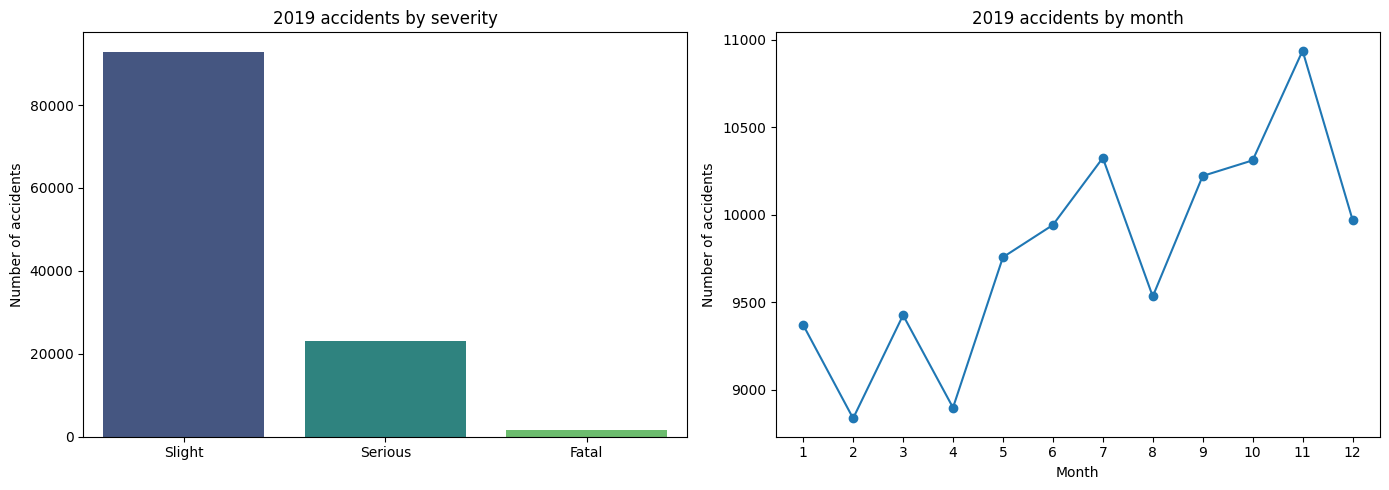

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#severity split 
sev_order = ['Slight', 'Serious', 'Fatal']
sns.countplot(data=accident_clean, x='severity_label', order=sev_order, ax=axes[0], palette='viridis')
axes[0].set_title('2019 accidents by severity')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of accidents')

#monthly count - checks for seasonality 
monthly = accident_clean.groupby('month').size()
axes[1].plot(monthly.index, monthly.values, marker='o')
axes[1].set_title('2019 accidents by month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of accidents')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

## Task 1: When do accidents happen
Answer: 
 - the overall hour-of-day / day-of-week pattern across all 2019 accidents
 -  the same pattern split by motorcycle engine-capacity band (125cc and under, over 125cc up to 500cc, over 500cc), and 
 - the same pattern for pedestrian casualties.

### 1a. Overall hour and day-of-week pattern

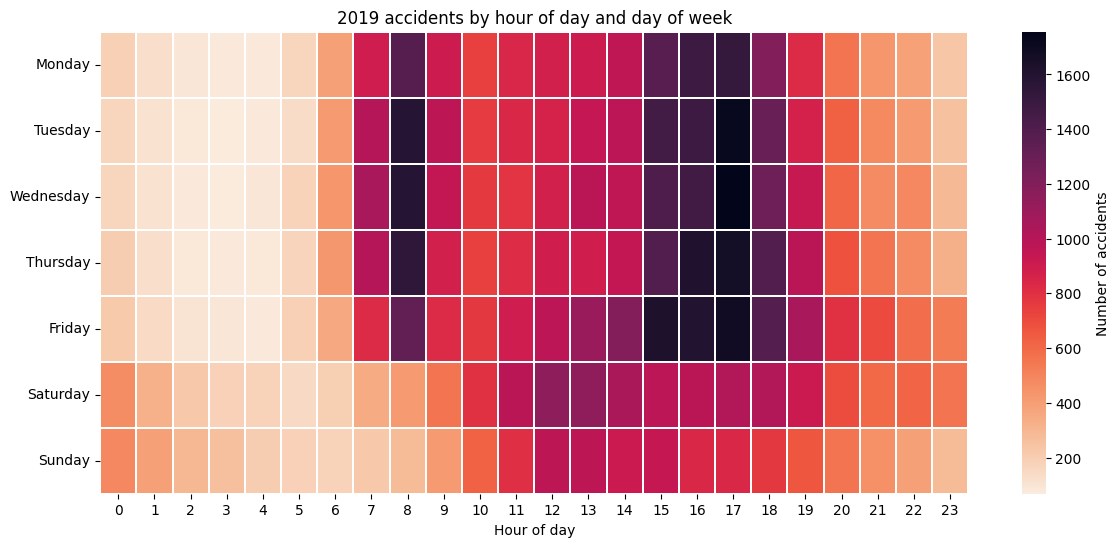

Busiest single hour overall: 17:00
Share of 2019 accidents on a weekday: 75.8%

Accidents per hour of day (all days):
hour
0      1893
1      1327
2       966
3       827
4       791
5      1169
6      2404
7      5353
8      8127
9      5497
10     5190
11     5960
12     6601
13     6946
14     6994
15     9172
16     9462
17    10198
18     8347
19     6234
20     4536
21     3703
22     3361
23     2478
Name: count, dtype: int64


In [25]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

#cross-tabulate hour of day against day of week
hour_day = pd.crosstab(accident_clean['day_name'], accident_clean['hour']).reindex(day_order)

plt.figure(figsize=(14, 6))
sns.heatmap(hour_day, cmap='rocket_r', linewidths=0.3, cbar_kws={'label': 'Number of accidents'})
plt.title('2019 accidents by hour of day and day of week')
plt.xlabel('Hour of day')
plt.ylabel('')
plt.show()


busiest_hour = accident_clean['hour'].value_counts().idxmax()
weekday_share = 1 - accident_clean['is_weekend'].mean()
print(f"Busiest single hour overall: {busiest_hour}:00")
print(f"Share of 2019 accidents on a weekday: {weekday_share:.1%}")
print()
print("Accidents per hour of day (all days):")
print(accident_clean['hour'].value_counts().sort_index())

Accidents were concentrated between 15:00 and 18:00 on weekdays, with 17:00 recording the highest number of accidents at 10,198. Friday was the busiest day, with 19,056 accidents, and approximately 76% of all 2019 accidents occurred on weekdays. A smaller peak was also observed around 08:00, corresponding to the morning commute. This pattern is likely driven by higher traffic exposure during school runs, shift changes, and evening commutes, combined with reduced visibility and driver fatigue. Weekends showed a flatter and later distribution, consistent with more leisure-based travel patterns.

### 1b. Motorcycles: 125cc and under vs. over 125cc-500cc vs. over 500cc

Motorcycle accidents are in the vehicle table, not accident, so we merge the motorcycle-only rows built above  onto accidents df to bring in hour and day_name. Each band is normalised to a proportion of its own total, so the three bands can be compared on the shape of their pattern rather than their volume.

Motorcycles involved in a 2019 accident: 15400
motorcycle_band
125cc and under           8053
Over 500cc                5228
Over 125cc up to 500cc    2119
Name: count, dtype: int64


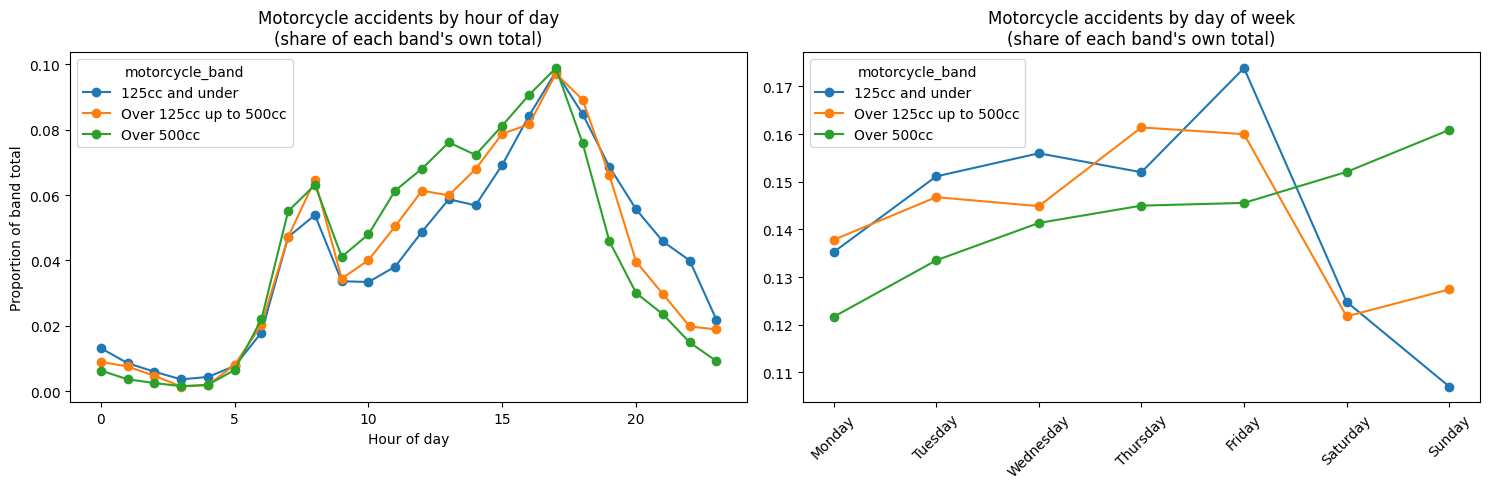


Weekend share of each band's accidents:
motorcycle_band
125cc and under           0.231839
Over 125cc up to 500cc    0.249174
Over 500cc                0.312930
Name: day_name, dtype: float64


In [26]:
def merge_with_time_features(df, id_col='accident_index'):
    """Attach hour/day_name from accident_clean onto any table keyed by accident_index.
    Reused here for motorcycles and again in Task 1c for pedestrians."""
    return df.merge(accident_clean[[id_col, 'hour', 'day_name']], on=id_col)

moto = merge_with_time_features(vehicle_clean.dropna(subset=['motorcycle_band']))
print(f"Motorcycles involved in a 2019 accident: {len(moto)}")
print(moto['motorcycle_band'].value_counts())

band_order = ['125cc and under', 'Over 125cc up to 500cc', 'Over 500cc']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

#hour of day shape, per band, as a proportion of that band's total
hour_props = pd.crosstab(moto['hour'], moto['motorcycle_band'], normalize='columns')
hour_props[band_order].plot(ax=axes[0], marker='o')
axes[0].set_title('Motorcycle accidents by hour of day\n(share of each band\'s own total)')
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Proportion of band total')

#day-of-week shape, per band
day_props = pd.crosstab(moto['day_name'], moto['motorcycle_band'], normalize='columns').reindex(day_order)
day_props[band_order].plot(ax=axes[1], marker='o')
axes[1].set_title('Motorcycle accidents by day of week\n(share of each band\'s own total)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nWeekend share of each band's accidents:")
print(moto.groupby('motorcycle_band')['day_name'].apply(lambda s: s.isin(['Saturday', 'Sunday']).mean())[band_order])

- All three bands share the same broad rush-hour shape (every band peaks around 17:00), because all motorcyclists are exposed to the same road network and traffic volumes as everyone else. 
- The difference is in the weekend share: over-500cc motorcycles have the highest weekend share of accidents (~31%), compared to ~25% for the 125-500cc band and ~23% for 125cc-and-under machines. 
- The 125cc-and-under band is also the most concentrated on Friday specifically. This is consistent with how these machines tend to be used in practice: smaller, cheaper bikes in the 125cc class are disproportionately used as learner/commuter transport (a 125cc licence is obtainable at 17 and commonly used for weekday commuting), so their accidents track the weekday commute closely. 
- Larger machines (500cc+) require a full motorcycle licence, cost more to own and insure, and are more often leisure vehicles ridden for pleasure at weekends - hence the larger weekend share. This has a direct policy implication: weekday CBT/commuter-focused road-safety messaging should target smaller-capacity riders, while weekend, rural, and "biker route" enforcement/awareness campaigns should target larger-capacity riders.

### 1c. Pedestrians

Pedestrian casualties are in the casualty table (casualty_class == 3), so the same merge pattern is used again, this time pulling hour and day_name onto every pedestrian casualty row.

Pedestrian casualties in 2019: 21770


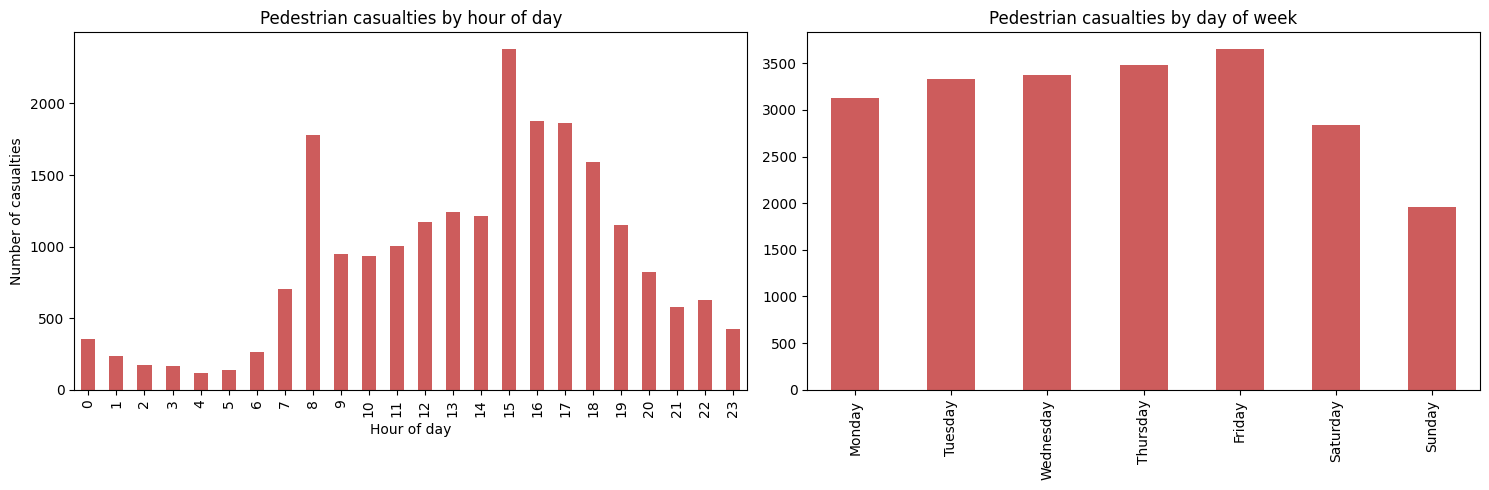


Top 5 hours for pedestrian casualties:
hour
15    2378
16    1879
17    1866
8     1779
18    1588
Name: count, dtype: int64


In [27]:
pedestrians = merge_with_time_features(casualty_clean[casualty_clean['casualty_class_label'] == 'Pedestrian'])
print(f"Pedestrian casualties in 2019: {len(pedestrians)}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

pedestrians['hour'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='indianred')
axes[0].set_title('Pedestrian casualties by hour of day')
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Number of casualties')

pedestrians['day_name'].value_counts().reindex(day_order).plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title('Pedestrian casualties by day of week')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

print("\nTop 5 hours for pedestrian casualties:")
print(pedestrians['hour'].value_counts().head(5))

- Pedestrian casualties peak sharply at 15:00 (2,378, the school run home), with a secondary evening peak at 16:00-18:00 and a distinct morning spike at 08:00 (1,779, the school/work run in). 
- Unlike the motorcycle bands, pedestrian casualties fall off steeply at weekends and are lowest on Sunday (1,964 vs. 3,649 on Friday).
- This points to a school-run and commuting effect specific to walking: children and commuters cross busy roads at the same narrow windows every weekday, on foot, with no protective structure around them, so any driver error at those times is far more likely to become a pedestrian casualty than at other times of day.
- This supports targeted interventions around school streets, 20mph zones near schools, and crossing-point enforcement concentrated on the 08:00 and 15:00-17:00 weekday windows, rather than blanket measures applied evenly across the week.

## Task 2: Apriori - what conditions go with accident severity?


In [28]:
#STATS19 manual lookups for the variables used
light_labels = {1: 'Daylight', 4: 'Darkness - lit', 5: 'Darkness - unlit',
                6: 'Darkness - no lighting', 7: 'Darkness - unknown lighting', -1: 'Unknown'}
weather_labels = {1: 'Fine, no high winds', 2: 'Raining, no high winds', 3: 'Snowing, no high winds',
                   4: 'Fine + high winds', 5: 'Raining + high winds', 6: 'Snowing + high winds',
                   7: 'Fog or mist', 8: 'Other', 9: 'Unknown', -1: 'Unknown'}
road_surface_labels = {1: 'Dry', 2: 'Wet or damp', 3: 'Snow', 4: 'Frost or ice',
                        5: 'Flood', 6: 'Oil or diesel', 7: 'Mud', -1: 'Unknown'}
area_labels = {1: 'Urban', 2: 'Rural', 3: 'Unallocated'}
junction_labels = {0: 'Not at junction', 1: 'Roundabout', 2: 'Mini-roundabout',
                    3: 'T or staggered junction', 5: 'Slip road', 6: 'Crossroads',
                    7: 'More than 4 arms', 8: 'Private drive/entrance', 9: 'Other junction', -1: 'Unknown'}

apriori_df = accident_clean.copy()
apriori_df['speed_limit_label'] = apriori_df['speed_limit'].astype(str) + 'mph'
apriori_df['light_label'] = apriori_df['light_conditions'].map(light_labels)
apriori_df['weather_label'] = apriori_df['weather_conditions'].map(weather_labels)
apriori_df['road_surface_label'] = apriori_df['road_surface_conditions'].map(road_surface_labels)
apriori_df['area_label'] = apriori_df['urban_or_rural_area'].map(area_labels)
apriori_df['junction_label'] = apriori_df['junction_detail'].map(junction_labels)

apriori_cols = ['severity_label', 'speed_limit_label', 'light_label', 'weather_label',
                'road_surface_label', 'area_label', 'junction_label']

#one-hot encode the columns
onehot = pd.get_dummies(apriori_df[apriori_cols], columns=apriori_cols, prefix=apriori_cols)
print(f"Transactions: {onehot.shape[0]}, one-hot items: {onehot.shape[1]}")

frequent_itemsets = apriori(onehot, min_support=0.01, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.05)
print(f"Frequent itemsets: {len(frequent_itemsets)}, rules: {len(rules)}")

Transactions: 117536, one-hot items: 44


Frequent itemsets: 1883, rules: 27794


In [29]:
def severity_rules(rules_df, severity_item, top_n=8):
    """Keep only the rules that (a) conclude in a single named severity level and
    (b) do not already contain a severity item in the antecedent (we want
    road/environment conditions -> severity, not severity -> severity)."""
    single_consequent = rules_df['consequents'].apply(lambda x: len(x) == 1 and severity_item in x)
    sub = rules_df.loc[single_consequent].copy()
    no_severity_antecedent = sub['antecedents'].apply(lambda x: not any('severity_label' in i for i in x))
    sub = sub.loc[no_severity_antecedent]
    return sub.sort_values('lift', ascending=False).head(top_n)[['antecedents', 'support', 'confidence', 'lift']]

print("Baseline severity rates:")
print(accident_clean['severity_label'].value_counts(normalize=True).round(3))

print("\nTop rules -> Serious severity (baseline 19.6%):")
display(severity_rules(rules, 'severity_label_Serious'))

Baseline severity rates:
severity_label
Slight     0.790
Serious    0.196
Fatal      0.014
Name: proportion, dtype: float64

Top rules -> Serious severity (baseline 19.6%):


,antecedents,support,confidence,lift
26483,"frozenset({weather_label_Fine, no high winds, ...",0.010669,0.320143,1.637438
20473,"frozenset({weather_label_Fine, no high winds, ...",0.010967,0.317019,1.621461
20576,"frozenset({junction_label_Not at junction, are...",0.010984,0.316499,1.618801
11028,"frozenset({speed_limit_label_60mph, light_labe...",0.011307,0.313739,1.604685
20629,"frozenset({weather_label_Fine, no high winds, ...",0.013494,0.313129,1.601565
11158,"frozenset({speed_limit_label_60mph, road_surfa...",0.014081,0.311970,1.595635
11106,"frozenset({speed_limit_label_60mph, road_surfa...",0.013860,0.309755,1.584305
3431,"frozenset({speed_limit_label_60mph, road_surfa...",0.014489,0.309074,1.580825


Fatal accidents are only 1.4% of the data, so a specific 4-5-condition combination that includes "Fatal" as a consequent rarely reaches 1% support - min_support=0.01 filters out every Fatal rule before we even get to look at them. To see how Fatal accidents relate to conditions, we lower min_support to 0.002 (roughly 235 accidents) for this one pass, which is still well above the level needed to trust that a pattern is not just one-off noise.

In [30]:
frequent_itemsets_rare = apriori(onehot, min_support=0.002, use_colnames=True)
rules_rare = association_rules(frequent_itemsets_rare, metric="confidence", min_threshold=0.02)
print(f"Frequent itemsets: {len(frequent_itemsets_rare)}, rules: {len(rules_rare)}")

print("\nTop rules -> Fatal severity (baseline 1.4%):")
display(severity_rules(rules_rare, 'severity_label_Fatal'))

Frequent itemsets: 5194, rules: 94221

Top rules -> Fatal severity (baseline 1.4%):


,antecedents,support,confidence,lift
25510,"frozenset({speed_limit_label_60mph, road_surfa...",0.002331,0.051649,3.661437
6090,"frozenset({speed_limit_label_60mph, road_surfa...",0.002399,0.051180,3.628139
621,"frozenset({light_label_Darkness - no lighting,...",0.002025,0.051007,3.615918
58360,"frozenset({weather_label_Fine, no high winds, ...",0.002195,0.050938,3.610993
25465,"frozenset({speed_limit_label_60mph, road_surfa...",0.002263,0.050580,3.585625
616,"frozenset({light_label_Darkness - no lighting,...",0.002229,0.047741,3.384337
25487,"frozenset({speed_limit_label_60mph, area_label...",0.002740,0.046939,3.327501
6068,"frozenset({speed_limit_label_60mph, weather_la...",0.002808,0.046387,3.288414


The same profile appears consistently across both tables: a 60mph speed limit, a rural area, a dry road surface, and no junction. For serious outcomes, this combination has approximately 32% confidence compared with a 19.6% baseline, giving a lift of around 1.6. For fatal outcomes, adding darkness and no street lighting increases the lift to approximately 3.3–3.7 against a 1.4% baseline. This indicates that accidents on unlit, 60mph rural roads away from junctions are more than three times as likely to be fatal as a randomly selected 2019 accident.

Severe outcomes are therefore not primarily associated with wet weather, snow, or poor road surfaces. Instead, speed and the lack of safety infrastructure, such as lighting, junctions, and urban traffic calming, appear more important. These findings support targeted interventions such as average-speed cameras on rural 60mph roads, improved lighting and high-visibility signage at rural hotspots, and greater prioritisation of rural road-safety audits.

## Task 3: Our region - Kingston upon Hull and East Riding of Yorkshire

In [31]:
def filter_by_lsoa_prefix(df, prefixes):
    """Keep rows whose LSOA name starts with any of the given place-name prefixes.
    Reused in Task 5 to isolate Hull-only accidents from this same accident_lsoa table."""
    if isinstance(prefixes, str):
        prefixes = (prefixes,)
    return df[df['lsoa01nm'].str.startswith(tuple(prefixes))]

#join accidents to their LSOA name, keep only Hull / East Riding LSOAs
accident_lsoa = accident_clean.merge(
    lsoa_df[['lsoa01cd', 'lsoa01nm']],
    left_on='lsoa_of_accident_location', right_on='lsoa01cd', how='inner'
)

#an inner join silently drops any accident whose LSOA code isn't in the lookup table
#(e.g. LSOA boundary changes) - check the match rate rather than let that pass unnoticed
match_rate = len(accident_lsoa) / len(accident_clean)
print(f"{match_rate:.1%} of 2019 accidents matched an LSOA name via the lookup table.")
if match_rate < 0.8:
    print("Warning: match rate looks unexpectedly low - check the LSOA join.")

region_df = filter_by_lsoa_prefix(accident_lsoa, ('Kingston upon Hull', 'East Riding of Yorkshire')).copy()
region_df['area'] = np.where(region_df['lsoa01nm'].str.startswith('Kingston upon Hull'), 'Hull', 'East Riding')

print(f"2019 accidents in our region: {len(region_df)}")
print(region_df['area'].value_counts())

region_df = region_df.dropna(subset=['latitude', 'longitude'])
print(f"\nWith usable coordinates: {len(region_df)}")

90.0% of 2019 accidents matched an LSOA name via the lookup table.
2019 accidents in our region: 1420
area
Hull           739
East Riding    681
Name: count, dtype: int64

With usable coordinates: 1420


#### Clustering 

With the region isolated, we cluster on latitude/longitude with KMeans and use elbow-method to choose k.

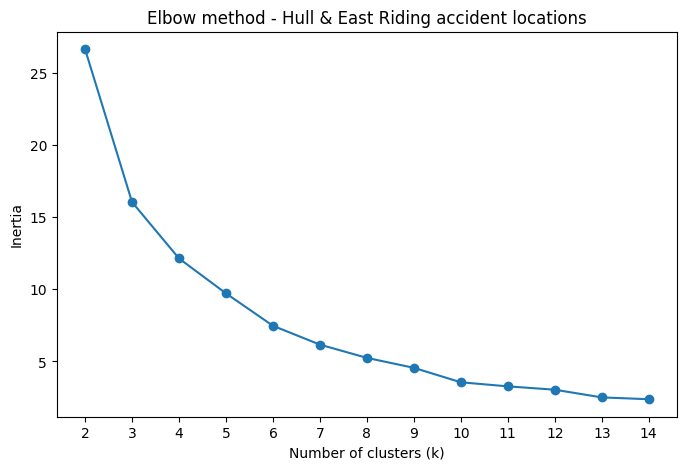

In [32]:
def kmeans_elbow(X, k_values):
    """Fit KMeans for each k in k_values and return the resulting inertia values,
    used to pick a cluster count via the elbow method."""
    inertias = []
    for k in k_values:
        km = KMeans(n_clusters=k, random_state=42, n_init="auto").fit(X)
        inertias.append(km.inertia_)
    return inertias

X_region = region_df[['latitude', 'longitude']].values
k_values = range(2, 15)
inertias = kmeans_elbow(X_region, k_values)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow method - Hull & East Riding accident locations')
plt.xticks(list(k_values))
plt.show()

The curve bends noticeably around k = 6 (the marginal drop in inertia flattens out from there), so we fit the final model with 6 clusters.

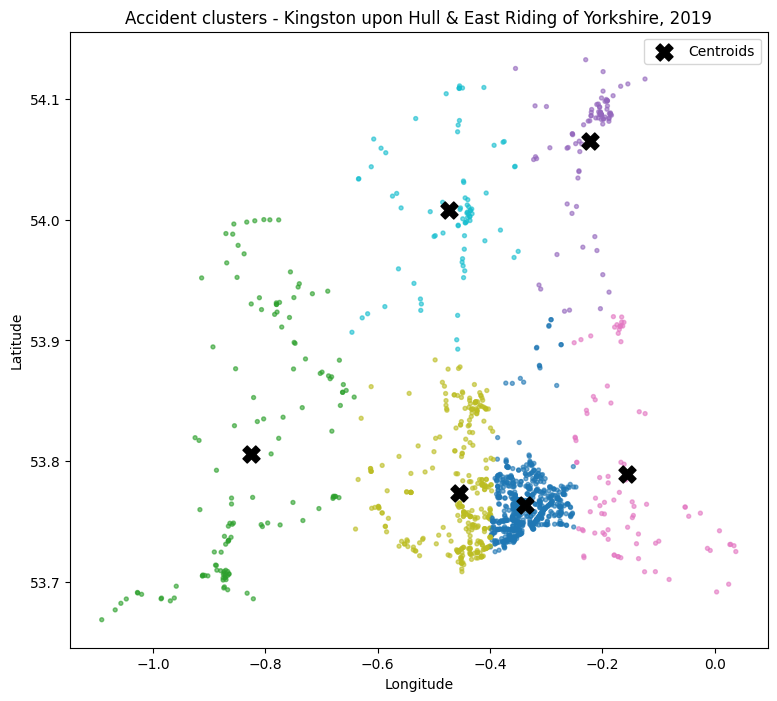

,n_accidents,pct_hull,pct_urban,avg_speed_limit,pct_fatal_or_serious
cluster,,,,,
0,724,0.953,0.945,30.856,0.184
1,129,0.000,0.163,49.380,0.256
2,87,0.000,0.483,37.126,0.218
3,85,0.000,0.106,42.941,0.235
4,316,0.155,0.620,39.557,0.187
5,79,0.000,0.228,48.987,0.253


In [33]:
#fit the final model at k= 6 and label every accident with its cluster
kmeans = KMeans(n_clusters=6, random_state=42, n_init="auto").fit(X_region)
region_df['cluster'] = kmeans.labels_
centroids = kmeans.cluster_centers_

plt.figure(figsize=(9, 8))
plt.scatter(region_df['longitude'], region_df['latitude'], c=region_df['cluster'], cmap='tab10', s=8, alpha=0.6)
plt.scatter(centroids[:, 1], centroids[:, 0], c='black', marker='X', s=150, label='Centroids')
plt.title('Accident clusters - Kingston upon Hull & East Riding of Yorkshire, 2019')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()

#profile each cluster: size, area split, urban/rural mix, average speed limit and severity mix
profile = region_df.groupby('cluster').agg(
    n_accidents=('cluster', 'size'),
    pct_hull=('area', lambda s: (s == 'Hull').mean()),
    pct_urban=('urban_or_rural_area', lambda s: (s == 1).mean()),
    avg_speed_limit=('speed_limit', 'mean'),
    pct_fatal_or_serious=('accident_severity', lambda s: (s <= 2).mean()),).round(3)
display(profile)

Cluster 0 (n=724) primarily represents urban Hull, with 95.3% of its points located in Hull LSOAs and 94.5% classified as urban. It also has the lowest average speed limit at 30.9 mph. Despite containing more than half of the region’s accidents, its KSI rate is relatively low at 18.4%.

The remaining five clusters are distributed across East Riding, covering market towns and rural roads. A clear pattern emerges, with more rural and higher-speed clusters showing higher KSI rates. Clusters 1 and 5, with average speed limits of 49.4 and 49.0 mph respectively, have the highest KSI rates at 25.6% and 25.3%, despite accounting for fewer than 200 accidents combined.

This reflects the national pattern identified in Task 2 at a local level: urban Hull experiences more accidents, while rural East Riding records more severe outcomes. Road-safety strategies should therefore differ, focusing on reducing accident frequency in Hull and addressing accident severity through targeted interventions on East Riding’s rural roads.

## Task 4: Forecasting Weekly Accidents for Three Police Forces

Three police forces were selected to assess whether forecasting accuracy changes with accident volume: Metropolitan Police, Humberside, and Cumbria. These represent large, medium, and small forces respectively.

Forecasting was treated as a supervised regression problem using a decision-tree ensemble rather than a classical ARIMA-based approach. Weekly accident counts were predicted using the previous four weeks’ counts, week of year, and a trend index. The model was trained on 2017–2018 data and evaluated on 2019, with performance compared against a naive baseline. A short lag window of one to four weeks was used instead of a 52-week seasonal lag, as the latter would substantially reduce the already limited training data.

In [34]:
def weekly_accident_counts(police_force_code):
    """Weekly accident counts for one police force, 2017-2019, indexed by
    calendar week-ending date so weeks line up continuously across year boundaries.
    Reusable for any police_force code, not just the three chosen below."""
    force_df = accident_all_clean[accident_all_clean['police_force'] == police_force_code]
    force_df = force_df[force_df['datetime'].between('2017-01-01', '2019-12-31')]
    return force_df.set_index('datetime').resample('W').size()

police_forces = {1: 'Metropolitan Police', 16: 'Humberside', 3: 'Cumbria'}
weekly_series = {code: weekly_accident_counts(code) for code in police_forces}

for code, name in police_forces.items():
    print(f"{name}: {len(weekly_series[code])} weekly observations, "
          f"mean {weekly_series[code].mean():.1f} accidents/week")

Metropolitan Police: 158 weekly observations, mean 488.2 accidents/week
Humberside: 158 weekly observations, mean 43.9 accidents/week
Cumbria: 158 weekly observations, mean 22.5 accidents/week


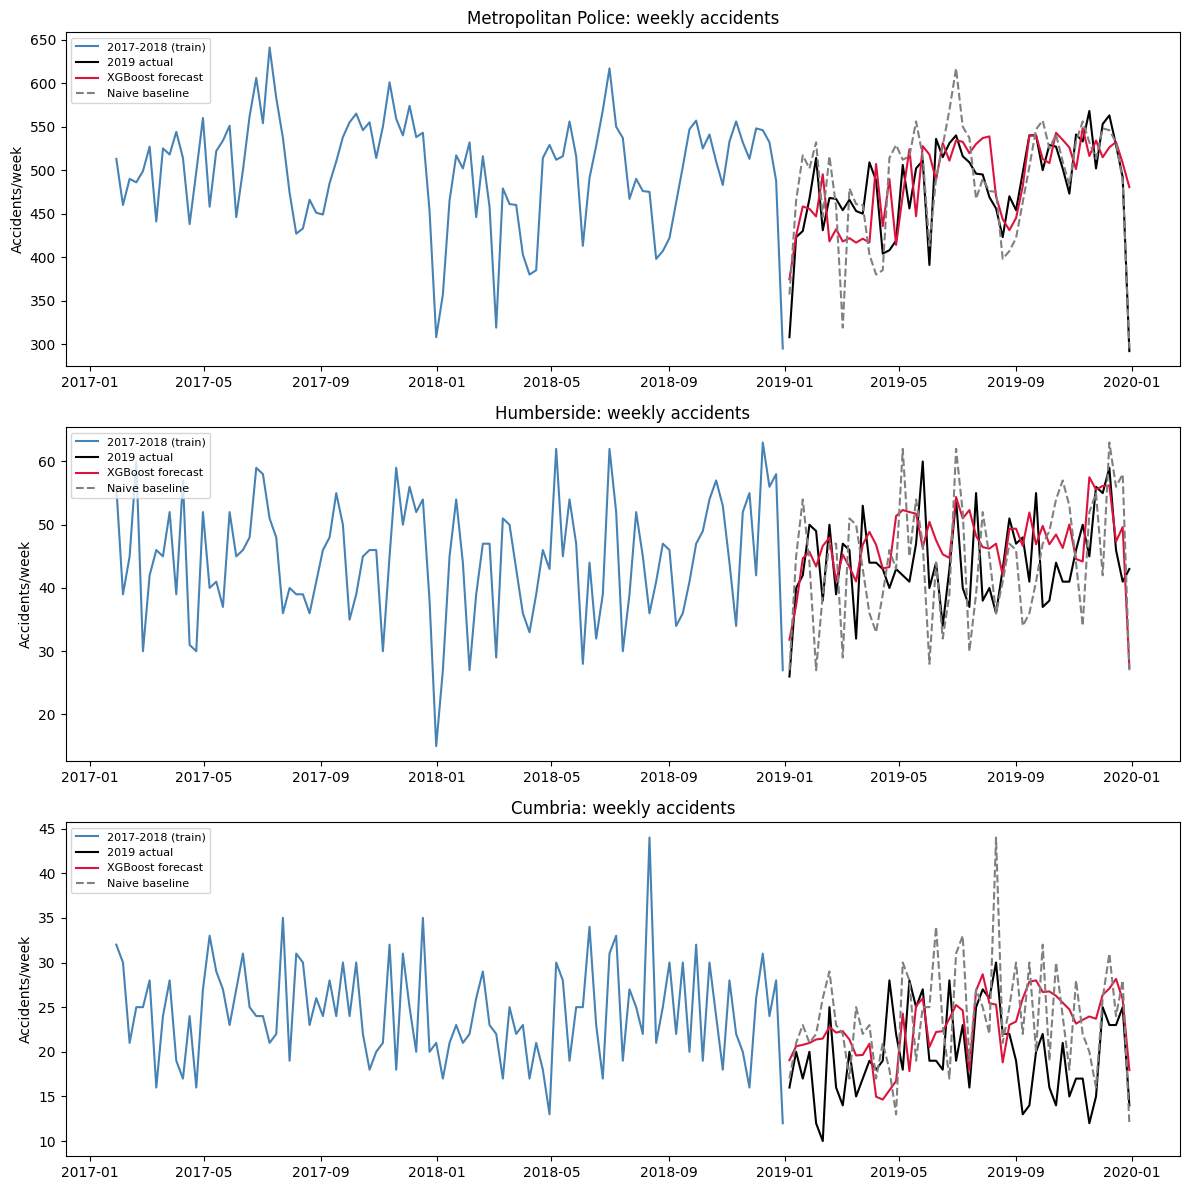

,model_rmse,model_mape,baseline_rmse,baseline_mape
Metropolitan Police,49.492,0.084,47.026,0.073
Humberside,7.386,0.146,10.382,0.196
Cumbria,6.332,0.307,7.677,0.351


In [35]:
def add_lag_features(series, lags=(1, 2, 3, 4)):
    """Turn a weekly count series into a supervised-learning table: each row's
    target is that week's count, and its features are the previous few weeks'
    counts, the week-of-year, and a simple trend index."""
    frame = series.to_frame('count')
    for lag in lags:
        frame[f'lag_{lag}'] = frame['count'].shift(lag)
    frame['week_of_year'] = frame.index.isocalendar().week.astype(int)
    frame['trend'] = range(len(frame))
    return frame.dropna()

FEATURE_COLS = ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'week_of_year', 'trend']

def fit_and_forecast(series, train_years=(2017, 2018), test_year=2019):
    """Fit an XGBoost regressor on the lag-feature table for train_years and
    predict test_year, alongside a naive 'repeat last year' baseline."""
    feat = add_lag_features(series)
    train = feat[feat.index.year.isin(train_years)]
    test = feat[feat.index.year == test_year]

    model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
    model.fit(train[FEATURE_COLS], train['count'])
    forecast = pd.Series(model.predict(test[FEATURE_COLS]), index=test.index)

    #naive baseline: this week's forecast = the same week last year
    baseline = pd.Series(train['count'].iloc[-len(test):].values, index=test.index)

    metrics = {
        'model_rmse': np.sqrt(mean_squared_error(test['count'], forecast)),
        'model_mape': mean_absolute_percentage_error(test['count'], forecast),
        'baseline_rmse': np.sqrt(mean_squared_error(test['count'], baseline)),
        'baseline_mape': mean_absolute_percentage_error(test['count'], baseline),
    }
    return train['count'], test['count'], forecast, baseline, metrics

results = {}
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=False)

#loop once per police force; a single force failing to fit shouldn't stop the other two
for ax, (code, name) in zip(axes, police_forces.items()):
    try:
        train, test, forecast, baseline, metrics = fit_and_forecast(weekly_series[code])
    except ValueError as exc:
        print(f"Could not fit a forecast model for {name}: {exc}")
        continue
    results[code] = metrics

    ax.plot(train.index, train.values, label='2017-2018 (train)', color='steelblue')
    ax.plot(test.index, test.values, label='2019 actual', color='black')
    ax.plot(test.index, forecast.values, label='XGBoost forecast', color='crimson')
    ax.plot(test.index, baseline.values, label='Naive baseline', color='grey', linestyle='--')
    ax.set_title(f"{name}: weekly accidents")
    ax.set_ylabel('Accidents/week')
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

metrics_df = pd.DataFrame(results).T
metrics_df.index = [police_forces[i] for i in metrics_df.index]
display(metrics_df.round(3))

The results were mixed rather than consistently favouring XGBoost. It outperformed the naive baseline for Humberside, with RMSE improving from 10.4 to 7.4 and MAPE from 19.6% to 14.6%, and for Cumbria, where RMSE decreased from 7.7 to 6.3 and MAPE from 35.1% to 30.7%. In contrast, XGBoost performed slightly worse for Metropolitan Police, with RMSE increasing from 47.0 to 49.5 and MAPE from 7.3% to 8.4%. With only around 101 usable training observations, the model could not improve on the strong naive baseline. Overall, the lag-based approach appears more useful for smaller forces, while larger and smoother series may require longer training histories or additional features to achieve consistent improvements.

## Task 5: Hull's top-30 LSOA hotspots - forecasting July from Jan-Jun

Step 1: rank Hull's LSOAs by accident count in **Q1 2019 (Jan-Mar)** and keep the top 30 - these are the borough's accident "hotspots" for the start of the year. Step 2: pool all 2019 accidents that fall in *those same 30 LSOAs* across **Jan-Jun 2019** into one daily count series, and use it to forecast daily accidents in **July 2019**.

In [36]:
#Hull accidents only
hull_df = filter_by_lsoa_prefix(accident_lsoa, 'Kingston upon Hull').copy()

q1_hull = hull_df[hull_df['datetime'].between('2019-01-01', '2019-03-31')]
top30_lsoas = q1_hull['lsoa01nm'].value_counts().head(30)

print(f"Q1 2019 accidents in Hull: {len(q1_hull)}")
print(f"Accidents in the top-30 LSOAs alone: {top30_lsoas.sum()} "
      f"(top LSOA: {top30_lsoas.index[0]} with {top30_lsoas.iloc[0]})")
display(top30_lsoas)

Q1 2019 accidents in Hull: 181
Accidents in the top-30 LSOAs alone: 114 (top LSOA: Kingston upon Hull 029A with 10)


lsoa01nm
Kingston upon Hull 029A    10
Kingston upon Hull 015C     7
Kingston upon Hull 029D     6
Kingston upon Hull 030B     6
Kingston upon Hull 024D     5
Kingston upon Hull 029C     5
Kingston upon Hull 026C     5
Kingston upon Hull 032A     4
Kingston upon Hull 016B     4
Kingston upon Hull 016D     4
Kingston upon Hull 020B     4
Kingston upon Hull 002A     4
Kingston upon Hull 016C     4
Kingston upon Hull 024B     4
Kingston upon Hull 015A     4
Kingston upon Hull 025C     3
Kingston upon Hull 022A     3
Kingston upon Hull 018B     3
Kingston upon Hull 020A     3
Kingston upon Hull 026D     3
Kingston upon Hull 024A     3
Kingston upon Hull 024E     3
Kingston upon Hull 012C     3
Kingston upon Hull 031E     2
Kingston upon Hull 017D     2
Kingston upon Hull 013C     2
Kingston upon Hull 028C     2
Kingston upon Hull 010A     2
Kingston upon Hull 012D     2
Kingston upon Hull 024C     2
Name: count, dtype: int64

Daily accident counts remained low even after pooling the 30 LSOAs, averaging about one accident per day. As in Task 4, the problem was framed as a supervised regression task using the previous three days’ counts, day of week, and a trend index as features for XGBoost. A three-day lag was retained after testing, as adding a seven-day lag reduced performance by shortening the already limited training period. Predictions were constrained to non-negative values and compared with a baseline using the training-period daily mean.

Training days: 178, total accidents: 185, mean/day: 1.04
July (test) days: 31, total accidents: 25


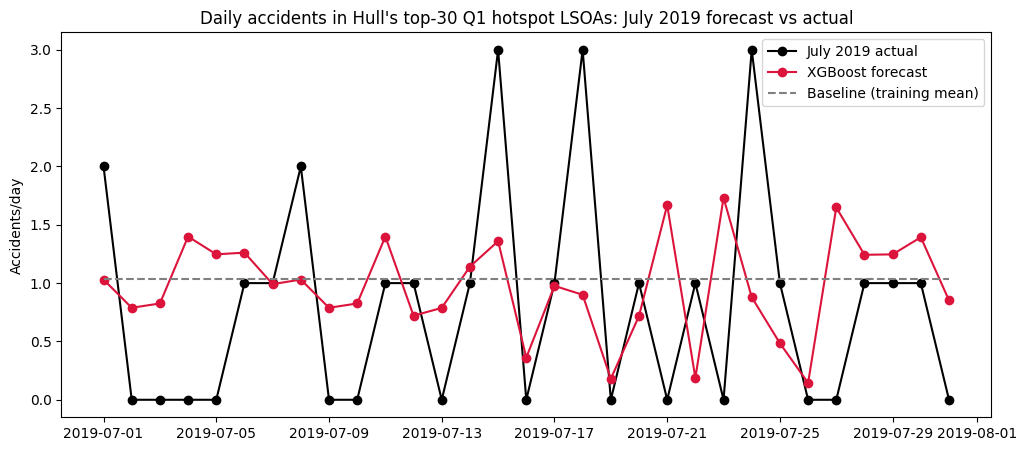

Model   -> MAE: 0.795, total predicted: 30.2 (actual: 25)
Baseline -> MAE: 0.736, total predicted: 32.2


In [37]:
def daily_counts_in_range(df, lsoa_names, start, end):
    """Daily accident counts for the given LSOAs between start and end (inclusive),
    zero-filled for days with no accidents. Reusable for any LSOA list / date window."""
    subset = df[df['lsoa01nm'].isin(lsoa_names) & df['datetime'].between(start, end)]
    return subset.set_index('datetime').resample('D').size().reindex(
        pd.date_range(start, end), fill_value=0)

def add_daily_lag_features(series, lags=(1, 2, 3)):
    """Turn a daily count series into a supervised-learning table: each row's
    target is that day's count, and its features are the last few days'
    counts, the day of week, and a simple trend index."""
    frame = series.to_frame('count')
    for lag in lags:
        frame[f'lag_{lag}'] = frame['count'].shift(lag)
    frame['day_of_week'] = frame.index.dayofweek
    frame['trend'] = range(len(frame))
    return frame.dropna()

DAILY_FEATURE_COLS = ['lag_1', 'lag_2', 'lag_3', 'day_of_week', 'trend']

top30_names = top30_lsoas.index.tolist()

#one continuous Jan-Jul daily series, so July's lag_1/2/3 come from real late-June
#days rather than being computed separately and losing that context
full_daily = daily_counts_in_range(hull_df, top30_names, '2019-01-01', '2019-07-31')
daily_features = add_daily_lag_features(full_daily)

daily_train = daily_features.loc['2019-01-01':'2019-06-30']
daily_test = daily_features.loc['2019-07-01':'2019-07-31']

print(f"Training days: {len(daily_train)}, total accidents: {daily_train['count'].sum()}, "
      f"mean/day: {daily_train['count'].mean():.2f}")
print(f"July (test) days: {len(daily_test)}, total accidents: {daily_test['count'].sum()}")

daily_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
daily_model.fit(daily_train[DAILY_FEATURE_COLS], daily_train['count'])
daily_forecast = pd.Series(
    np.clip(daily_model.predict(daily_test[DAILY_FEATURE_COLS]), 0, None), index=daily_test.index
)

daily_baseline = pd.Series(daily_train['count'].mean(), index=daily_test.index)

plt.figure(figsize=(12, 5))
plt.plot(daily_test.index, daily_test['count'].values, label='July 2019 actual', marker='o', color='black')
plt.plot(daily_forecast.index, daily_forecast.values, label='XGBoost forecast', marker='o', color='crimson')
plt.plot(daily_baseline.index, daily_baseline.values, label='Baseline (training mean)', linestyle='--', color='grey')
plt.title('Daily accidents in Hull\'s top-30 Q1 hotspot LSOAs: July 2019 forecast vs actual')
plt.ylabel('Accidents/day')
plt.legend()
plt.show()

print(f"Model   -> MAE: {mean_absolute_error(daily_test['count'], daily_forecast):.3f}, "
      f"total predicted: {daily_forecast.sum():.1f} (actual: {daily_test['count'].sum()})")
print(f"Baseline -> MAE: {mean_absolute_error(daily_test['count'], daily_baseline):.3f}, "
      f"total predicted: {daily_baseline.sum():.1f}")

July 2019 recorded 25 accidents across the 30 hotspot LSOAs. XGBoost predicted the monthly total more accurately than the baseline, but the baseline achieved a slightly lower day-level MAE. With only 178 usable training observations and roughly one accident per day across 30 areas, daily counts are too sparse for reliable day-specific forecasting. The model is therefore better suited to estimating monthly accident volumes for area-level resource planning than predicting individual days. The top-30 hotspot list should also be reviewed regularly to reflect changes in accident patterns.

In [4]:
#close the database connection 
con.close()

## recommendations 

1. Target enforcement and awareness campaigns by time, not just place.
2. Split motorcycle safety messaging by machine size.
3. Prioritise speed and rural road infrastructure over weather-driven interventions.
4. Use forecasts for monthly resourcing, not day-level micro-planning, and expect the value to depend on scale.
5. Keep hotspot lists under review.